# Análisis Exploratorio de Datos (EDA) — Dataset Brazilian E-commerce (Olist)
### Proyecto Integrador *Ecommify* · Unidad 1: Fundamentos de diseño y modelado de datos

**Objetivo del notebook.** Cumplir la *Metodología* de la sección **Presentación del proyecto integrador**:

1. Articular Google Colab con Google Drive (donde residen los CSV del dataset).
2. Cargar los **9 datasets** de Olist.
3. Ejecutar un EDA fundamental:
   - Revisar estructura con `df.info()` y `df.describe()`.
   - Identificar relaciones entre tablas (modelo conceptual / claves).
   - Analizar calidad de datos y valores nulos.
   - Visualizar distribuciones temporales y geográficas.
4. Documentar hallazgos sobre **estructura, volumen y características** de los datos.

> **Contexto.** *Ecommify* es una plataforma de comercio electrónico multivendedor. El proyecto integrador
> diseñará una arquitectura híbrida **PostgreSQL + MongoDB**. Este EDA es la línea base que justificará,
> más adelante, qué entidades viven en el motor relacional (transaccional) y cuáles en el documental (analítico).


## 1. Articulación con Google Drive

**Por qué montar Drive y no subir archivos a la sesión:** la VM de Colab es efímera (se borra al cerrar la sesión).
Montar Drive da persistencia, evita resubir ~1 millón de filas de `geolocation` en cada ejecución y permite que
todo el equipo trabaje sobre la **misma carpeta organizada** (entregable de la metodología).


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Ajusta `DATA_DIR` a la ruta de la carpeta donde subiste los CSV en tu Drive.
Sugerencia de organización del entregable: `MyDrive/Ecommify/data/brazilian-ecommerce/`.


In [4]:
import os

# Ruta de la carpeta donde están los datos en Google Drive
DATA_DIR = '/content/drive/MyDrive/Ecommify'

assert os.path.isdir(DATA_DIR), f'No existe la carpeta: {DATA_DIR}. Revisa la ruta en tu Drive.'
print('Archivos encontrados en la carpeta:')
for f in sorted(os.listdir(DATA_DIR)):
    if f.endswith('.csv'):
        size_mb = os.path.getsize(os.path.join(DATA_DIR, f)) / 1024**2
        print(f'  - {f:<45} {size_mb:6.1f} MB')

Archivos encontrados en la carpeta:
  - olist_customers_dataset.csv                      8.6 MB
  - olist_geolocation_dataset.csv                   58.4 MB
  - olist_order_items_dataset.csv                   14.7 MB
  - olist_order_payments_dataset.csv                 5.5 MB
  - olist_order_reviews_dataset.csv                 13.8 MB
  - olist_orders_dataset.csv                        16.8 MB
  - olist_products_dataset.csv                       2.3 MB
  - olist_sellers_dataset.csv                        0.2 MB
  - product_category_name_translation.csv            0.0 MB


## 2. Carga de los 9 datasets

Cargamos todas las tablas en un diccionario `dfs` para iterar de forma uniforme.
Parseamos columnas de fecha desde el inicio: el tipo correcto (`datetime64`) es lo que habilita el
análisis temporal y, conceptualmente, anticipa los `TIMESTAMP` de PostgreSQL en la fase física.


In [5]:
import pandas as pd

FILES = {
    'customers':            'olist_customers_dataset.csv',
    'geolocation':          'olist_geolocation_dataset.csv',
    'order_items':          'olist_order_items_dataset.csv',
    'order_payments':       'olist_order_payments_dataset.csv',
    'order_reviews':        'olist_order_reviews_dataset.csv',
    'orders':               'olist_orders_dataset.csv',
    'products':             'olist_products_dataset.csv',
    'sellers':              'olist_sellers_dataset.csv',
    'category_translation': 'product_category_name_translation.csv',
}

DATE_COLS = {
    'orders': ['order_purchase_timestamp', 'order_approved_at',
              'order_delivered_carrier_date', 'order_delivered_customer_date',
              'order_estimated_delivery_date'],
    'order_items': ['shipping_limit_date'],
    'order_reviews': ['review_creation_date', 'review_answer_timestamp'],
}

dfs = {}
for name, fname in FILES.items():
    dfs[name] = pd.read_csv(os.path.join(DATA_DIR, fname),
                            parse_dates=DATE_COLS.get(name))
    print(f'{name:<22} -> {dfs[name].shape[0]:>9,} filas x {dfs[name].shape[1]} columnas')

customers              ->    99,441 filas x 5 columnas
geolocation            -> 1,000,163 filas x 5 columnas
order_items            ->   112,650 filas x 7 columnas
order_payments         ->   103,886 filas x 5 columnas
order_reviews          ->    99,224 filas x 7 columnas
orders                 ->    99,441 filas x 8 columnas
products               ->    32,951 filas x 9 columnas
sellers                ->     3,095 filas x 4 columnas
category_translation   ->        71 filas x 2 columnas


### Volumen global del dataset
Una vista rápida del tamaño de cada tabla nos dice dónde estarán los retos de rendimiento
(p. ej. `geolocation` con ~1M filas) y dimensiona el proyecto frente a los límites del plan gratuito.


In [6]:
resumen = pd.DataFrame({
    'filas':    {k: len(v) for k, v in dfs.items()},
    'columnas': {k: v.shape[1] for k, v in dfs.items()},
    'memoria_MB': {k: round(v.memory_usage(deep=True).sum()/1024**2, 1) for k, v in dfs.items()},
}).sort_values('filas', ascending=False)
resumen.loc['TOTAL'] = [resumen['filas'].sum(), resumen['columnas'].sum(), round(resumen['memoria_MB'].sum(),1)]
resumen

,filas,columnas,memoria_MB
geolocation,1000163.0,5.0,129.4
order_items,112650.0,7.0,29.5
order_payments,103886.0,5.0,16.2
customers,99441.0,5.0,26.6
orders,99441.0,8.0,24.7
order_reviews,99224.0,7.0,27.8
products,32951.0,9.0,6.3
sellers,3095.0,4.0,0.6
category_translation,71.0,2.0,0.0
TOTAL,1550922.0,52.0,261.1


## 3. Estructura de los datos: `df.info()` y `df.describe()`

`info()` muestra tipos y no-nulos por columna; `describe()` resume las variables numéricas
(rango, media, percentiles). Juntas revelan qué columnas son identificadores, cuáles son métricas
y dónde hay datos faltantes.


In [7]:
for name, df in dfs.items():
    print('=' * 70)
    print(f'TABLA: {name}')
    print('=' * 70)
    df.info()
    print()

TABLA: customers
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB

TABLA: geolocation
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocatio

In [8]:
# Resumen estadístico de variables numéricas (tabla por tabla)
for name, df in dfs.items():
    num = df.select_dtypes('number')
    if num.shape[1]:
        print(f'\n----- describe(): {name} -----')
        display(num.describe().T)


----- describe(): customers -----


,count,mean,std,min,25%,50%,75%,max
customer_zip_code_prefix,99441.0,35137.474583,29797.938996,1003.0,11347.0,24416.0,58900.0,99990.0



----- describe(): geolocation -----


,count,mean,std,min,25%,50%,75%,max
geolocation_zip_code_prefix,1000163.0,36574.166466,30549.335710,1001.000000,11075.000000,26530.000000,63504.000000,99990.000000
geolocation_lat,1000163.0,-21.176153,5.715866,-36.605374,-23.603546,-22.919377,-19.979620,45.065933
geolocation_lng,1000163.0,-46.390541,4.269748,-101.466766,-48.573172,-46.637879,-43.767709,121.105394



----- describe(): order_items -----


...

,count,mean,std,min,25%,50%,75%,max
review_score,99224.0,4.086421,1.347579,1.0,4.0,5.0,5.0,5.0



----- describe(): products -----


,count,mean,std,min,25%,50%,75%,max
product_name_lenght,32341.0,48.476949,10.245741,5.0,42.0,51.0,57.0,76.0
product_description_lenght,32341.0,771.495285,635.115225,4.0,339.0,595.0,972.0,3992.0
product_photos_qty,32341.0,2.188986,1.736766,1.0,1.0,1.0,3.0,20.0
product_weight_g,32949.0,2276.472488,4282.038731,0.0,300.0,700.0,1900.0,40425.0
product_length_cm,32949.0,30.815078,16.914458,7.0,18.0,25.0,38.0,105.0
product_height_cm,32949.0,16.937661,13.637554,2.0,8.0,13.0,21.0,105.0
product_width_cm,32949.0,23.196728,12.079047,6.0,15.0,20.0,30.0,118.0



----- describe(): sellers -----


,count,mean,std,min,25%,50%,75%,max
seller_zip_code_prefix,3095.0,32291.059451,32713.45383,1001.0,7093.5,14940.0,64552.5,99730.0


In [9]:
# Muestra de las primeras filas de cada tabla
for name, df in dfs.items():
    print(f'\n----- head(): {name} -----')
    display(df.head(3))


----- head(): customers -----


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP



----- head(): geolocation -----


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP



----- head(): order_items -----


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0



----- head(): sellers -----


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ



----- head(): category_translation -----


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto


## 4. Relaciones entre tablas (modelo conceptual y claves)

Olist es un esquema en **estrella alrededor de `orders`**. Las claves que conectan las tablas son:

| Relación | Clave | Cardinalidad |
|---|---|---|
| `customers` → `orders` | `customer_id` | 1 cliente : N pedidos |
| `orders` → `order_items` | `order_id` | 1 pedido : N ítems |
| `orders` → `order_payments` | `order_id` | 1 pedido : N pagos |
| `orders` → `order_reviews` | `order_id` | 1 pedido : 0..N reviews |
| `products` → `order_items` | `product_id` | 1 producto : N ítems |
| `sellers` → `order_items` | `seller_id` | 1 vendedor : N ítems |
| `products` → `category_translation` | `product_category_name` | N productos : 1 categoría |
| `customers`/`sellers` → `geolocation` | `zip_code_prefix` | N : N (prefijo no es único) |

**Por qué importa para el proyecto integrador:** estas claves son las futuras *Foreign Keys* en PostgreSQL.
Validamos la **integridad referencial** ahora para saber qué tan limpio está el dataset antes de modelarlo.
Nota: `geolocation_zip_code_prefix` **no es único** (varias lat/lng por prefijo), por eso esa relación es N:N
y candidata a tratamiento especial (agregación o documento embebido en MongoDB).


In [10]:
# Validación de integridad referencial: ¿hay claves huérfanas?
def huerfanos(hijo, col_hijo, padre, col_padre):
    faltan = set(dfs[hijo][col_hijo].dropna()) - set(dfs[padre][col_padre].dropna())
    return len(faltan)

checks = [
    ('order_items',    'order_id',   'orders',   'order_id'),
    ('order_payments', 'order_id',   'orders',   'order_id'),
    ('order_reviews',  'order_id',   'orders',   'order_id'),
    ('orders',         'customer_id','customers','customer_id'),
    ('order_items',    'product_id', 'products', 'product_id'),
    ('order_items',    'seller_id',  'sellers',  'seller_id'),
]
print('Claves huérfanas (idealmente 0 => integridad referencial intacta):\n')
for hijo, ch, padre, cp in checks:
    n = huerfanos(hijo, ch, padre, cp)
    estado = 'OK' if n == 0 else 'REVISAR'
    print(f'  {hijo}.{ch} -> {padre}.{cp:<12} huérfanos = {n:>5}  [{estado}]')

# Pedidos sin review (relación 0..N)
sin_review = set(dfs['orders']['order_id']) - set(dfs['order_reviews']['order_id'])
print(f'\nPedidos sin ningún review: {len(sin_review):,} '
      f'({len(sin_review)/len(dfs["orders"]):.1%} del total)')

Claves huérfanas (idealmente 0 => integridad referencial intacta):

  order_items.order_id -> orders.order_id     huérfanos =     0  [OK]
  order_payments.order_id -> orders.order_id     huérfanos =     0  [OK]
  order_reviews.order_id -> orders.order_id     huérfanos =     0  [OK]
  orders.customer_id -> customers.customer_id  huérfanos =     0  [OK]
  order_items.product_id -> products.product_id   huérfanos =     0  [OK]
  order_items.seller_id -> sellers.seller_id    huérfanos =     0  [OK]

Pedidos sin ningún review: 768 (0.8% del total)


## 5. Calidad de datos y valores nulos

Cuantificamos nulos y duplicados. **Por qué:** los nulos definen restricciones `NOT NULL` en el diseño
físico y los duplicados nos dicen si una columna puede ser `PRIMARY KEY`/`UNIQUE`.


In [11]:
# Resumen de nulos por tabla y columna (solo columnas con faltantes)
for name, df in dfs.items():
    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0]
    if len(nulos):
        tabla = pd.DataFrame({'nulos': nulos, 'pct': (nulos/len(df)*100).round(2)})
        print(f'\n----- {name} -----')
        display(tabla)
    else:
        print(f'{name}: sin valores nulos ✔')

customers: sin valores nulos ✔
geolocation: sin valores nulos ✔
order_items: sin valores nulos ✔
order_payments: sin valores nulos ✔

----- order_reviews -----


,nulos,pct
review_comment_title,87656,88.34
review_comment_message,58247,58.70



----- orders -----


,nulos,pct
order_approved_at,160,0.16
order_delivered_carrier_date,1783,1.79
order_delivered_customer_date,2965,2.98



----- products -----


,nulos,pct
product_category_name,610,1.85
product_name_lenght,610,1.85
product_description_lenght,610,1.85
product_photos_qty,610,1.85
product_weight_g,2,0.01
product_length_cm,2,0.01
product_height_cm,2,0.01
product_width_cm,2,0.01


sellers: sin valores nulos ✔
category_translation: sin valores nulos ✔


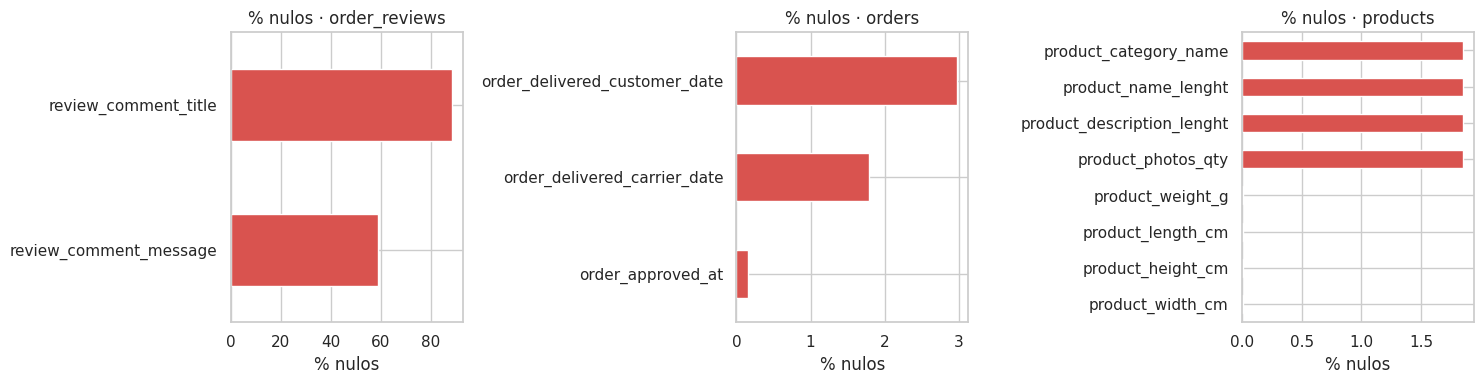

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

# % de nulos por columna, solo tablas que tienen faltantes
tablas_con_nulos = {n: d for n, d in dfs.items() if d.isnull().any().any()}
fig, axes = plt.subplots(1, len(tablas_con_nulos), figsize=(5*len(tablas_con_nulos), 4))
if len(tablas_con_nulos) == 1: axes = [axes]
for ax, (name, df) in zip(axes, tablas_con_nulos.items()):
    pct = (df.isnull().mean()*100)
    pct = pct[pct > 0].sort_values()
    pct.plot.barh(ax=ax, color='#d9534f')
    ax.set_title(f'% nulos · {name}')
    ax.set_xlabel('% nulos')
plt.tight_layout(); plt.show()

In [ ]:
# Duplicados por clave candidata a PRIMARY KEY
claves_pk = {
    'customers': 'customer_id', 'orders': 'order_id',
    'products': 'product_id', 'sellers': 'seller_id',
    'order_reviews': 'review_id',
}
print('Duplicados en claves primarias candidatas:')
for tabla, pk in claves_pk.items():
    dup = dfs[tabla][pk].duplicated().sum()
    print(f'  {tabla}.{pk:<14} duplicados = {dup}')

# customer_unique_id: identifica a la persona real (un cliente recurrente)
cu = dfs['customers']['customer_unique_id'].nunique()
print(f'\ncustomer_id distintos:        {dfs["customers"]["customer_id"].nunique():,}')
print(f'customer_unique_id distintos: {cu:,}  <- personas reales (hay clientes recurrentes)')

## 6. Distribuciones temporales

El dataset cubre pedidos entre **sept-2016 y oct-2018**. Visualizamos el volumen mensual
y los tiempos de entrega: insumos directos para decisiones de **particionamiento por fecha**
e índices en el módulo transaccional.


Rango temporal de pedidos: 2016-09-04 21:15:19 -> 2018-10-17 17:30:18


/tmp/ipykernel_446/4162839066.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M').size())


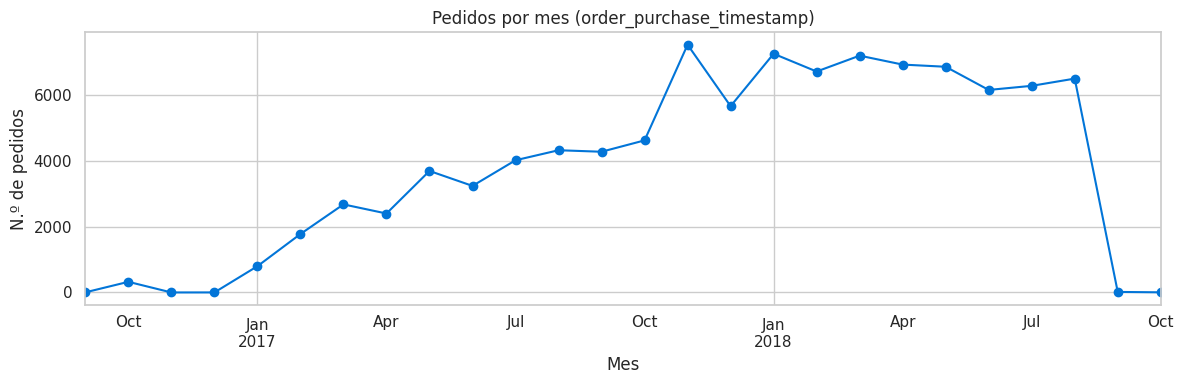

In [13]:
orders = dfs['orders']
print('Rango temporal de pedidos:',
      orders['order_purchase_timestamp'].min(), '->',
      orders['order_purchase_timestamp'].max())

# Pedidos por mes
por_mes = (orders.set_index('order_purchase_timestamp')
                 .resample('M').size())
plt.figure(figsize=(12, 4))
por_mes.plot(marker='o', color='#0275d8')
plt.title('Pedidos por mes (order_purchase_timestamp)')
plt.ylabel('N.º de pedidos'); plt.xlabel('Mes')
plt.tight_layout(); plt.show()

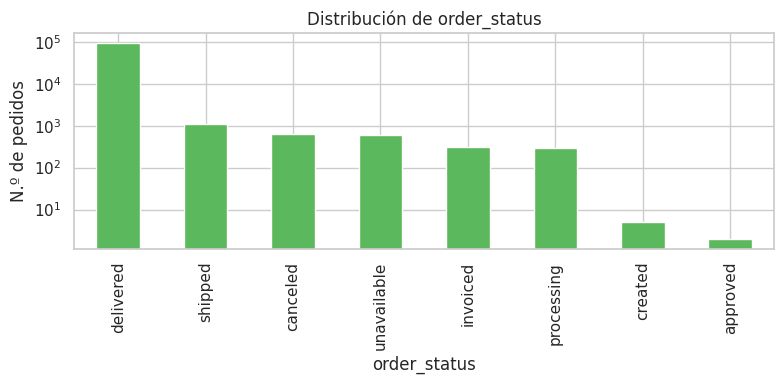

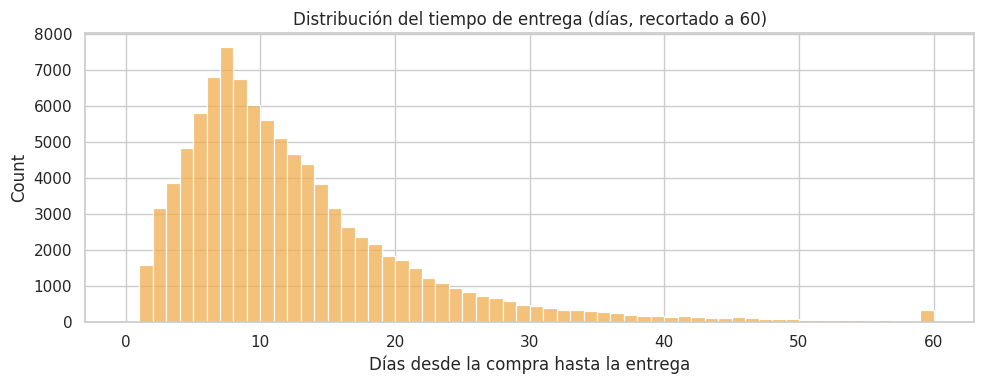

count    96476.0
mean        12.1
std          9.6
min          0.0
25%          6.0
50%         10.0
75%         15.0
max        209.0
Name: dias_entrega, dtype: float64


In [14]:
# Estado de los pedidos
plt.figure(figsize=(8, 4))
orders['order_status'].value_counts().plot.bar(color='#5cb85c')
plt.title('Distribución de order_status')
plt.ylabel('N.º de pedidos')
plt.yscale('log')  # escala log: 'delivered' domina ampliamente
plt.tight_layout(); plt.show()

# Tiempo de entrega real (días) en pedidos entregados
ent = orders.dropna(subset=['order_delivered_customer_date']).copy()
ent['dias_entrega'] = (ent['order_delivered_customer_date']
                       - ent['order_purchase_timestamp']).dt.days
plt.figure(figsize=(10, 4))
sns.histplot(ent['dias_entrega'].clip(0, 60), bins=60, color='#f0ad4e')
plt.title('Distribución del tiempo de entrega (días, recortado a 60)')
plt.xlabel('Días desde la compra hasta la entrega')
plt.tight_layout(); plt.show()
print(ent['dias_entrega'].describe().round(1))

## 6b. Distribuciones geográficas

Brasil concentra fuertemente la actividad en el sudeste (**SP, RJ, MG**). Esto afecta el diseño:
la geografía es un eje natural de análisis y un posible criterio de *sharding* en MongoDB.


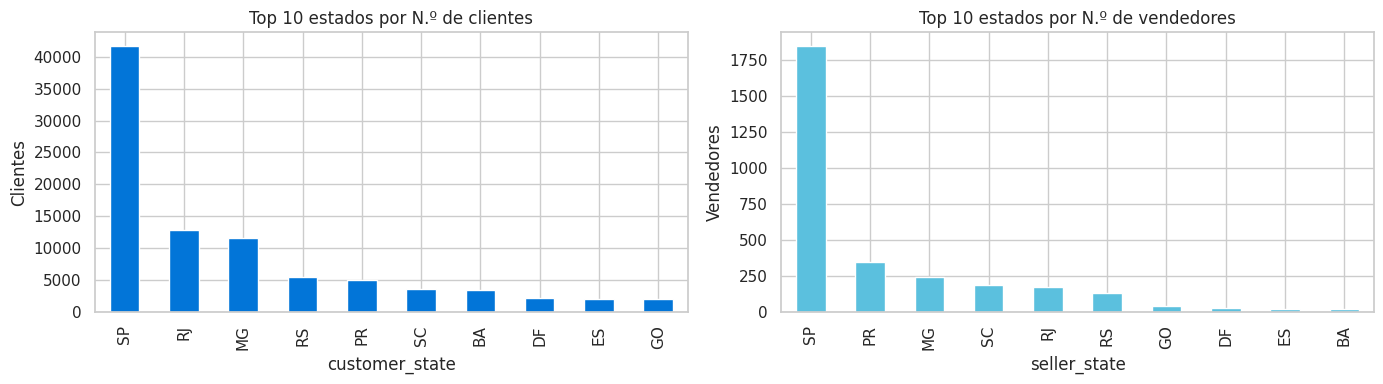

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Clientes por estado (top 10)
dfs['customers']['customer_state'].value_counts().head(10).plot.bar(
    ax=axes[0], color='#0275d8')
axes[0].set_title('Top 10 estados por N.º de clientes')
axes[0].set_ylabel('Clientes')

# Vendedores por estado (top 10)
dfs['sellers']['seller_state'].value_counts().head(10).plot.bar(
    ax=axes[1], color='#5bc0de')
axes[1].set_title('Top 10 estados por N.º de vendedores')
axes[1].set_ylabel('Vendedores')
plt.tight_layout(); plt.show()

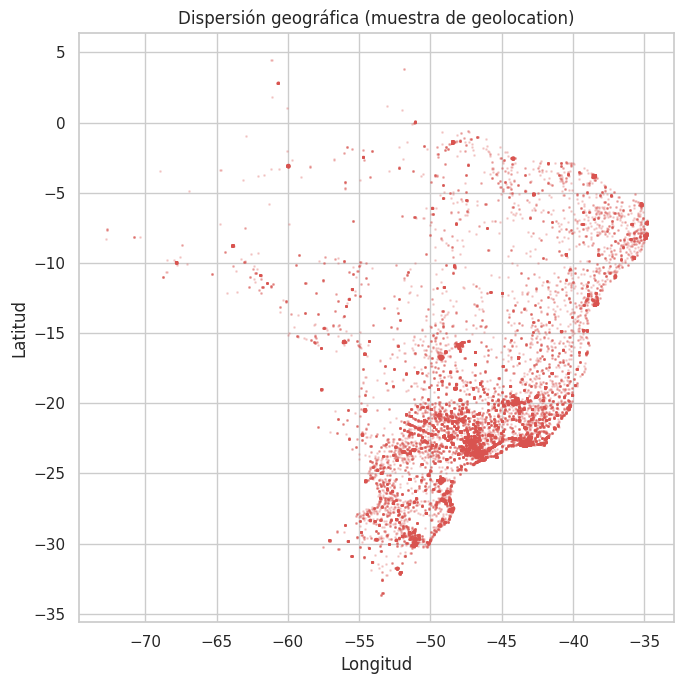

In [16]:
# Mapa de calor geográfico con coordenadas de geolocation (muestra para que sea ágil)
geo = dfs['geolocation'].sample(min(50000, len(dfs['geolocation'])), random_state=42)
# Recorte aproximado a la bounding box de Brasil para descartar outliers de coordenadas
geo = geo[(geo['geolocation_lat'].between(-34, 5)) &
          (geo['geolocation_lng'].between(-74, -34))]
plt.figure(figsize=(7, 7))
plt.scatter(geo['geolocation_lng'], geo['geolocation_lat'], s=1, alpha=0.2, color='#d9534f')
plt.title('Dispersión geográfica (muestra de geolocation)')
plt.xlabel('Longitud'); plt.ylabel('Latitud')
plt.tight_layout(); plt.show()

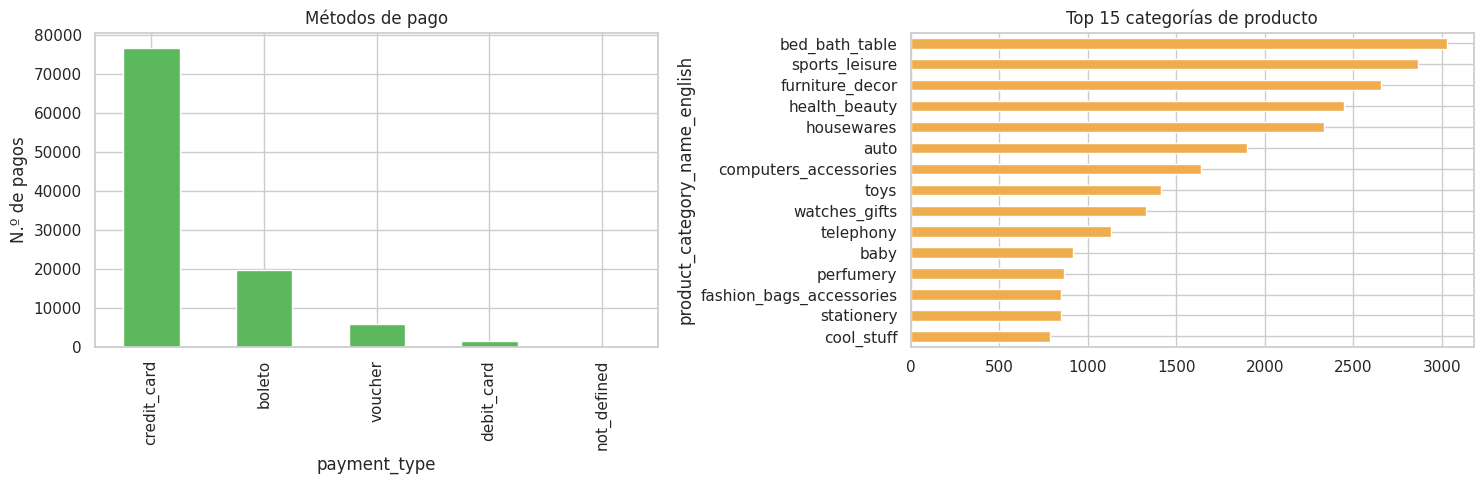

In [17]:
# Métodos de pago y categorías de producto (características del negocio)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

dfs['order_payments']['payment_type'].value_counts().plot.bar(
    ax=axes[0], color='#5cb85c')
axes[0].set_title('Métodos de pago')
axes[0].set_ylabel('N.º de pagos')

# Top categorías traducidas a inglés
prod = dfs['products'].merge(dfs['category_translation'], on='product_category_name', how='left')
prod['product_category_name_english'].value_counts().head(15).plot.barh(
    ax=axes[1], color='#f0ad4e')
axes[1].set_title('Top 15 categorías de producto')
axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

## 7. Documentación de hallazgos

### Estructura
- **9 tablas** en esquema estrella alrededor de `orders`. Claves bien definidas: `order_id`,
  `customer_id`, `product_id`, `seller_id`, `product_category_name`.
- **Integridad referencial intacta** entre pedidos, ítems, pagos, productos y vendedores (0 huérfanos),
  lo que valida modelar estas relaciones como *Foreign Keys* en PostgreSQL.
- `customer_id` ≠ `customer_unique_id`: el primero es por pedido; el segundo identifica a la **persona real**
  (existen clientes recurrentes). Distinción clave para análisis de comportamiento.
- `geolocation_zip_code_prefix` **no es único** → relación N:N; conviene agregarla o embeberla.

### Volumen
- ~**1.0 M** filas en `geolocation`, ~**113 K** en `order_items`, ~**104 K** en `order_payments`,
  ~**99 K** en `orders`/`customers`/`reviews`, **33 K** productos, **3 K** vendedores.
- Ventana temporal: **sept-2016 a oct-2018**; el grueso de pedidos es de 2017-2018.

### Calidad
- Tablas transaccionales (`orders`, `order_items`, `order_payments`) prácticamente **sin nulos** (solo fechas
  logísticas faltan cuando el pedido no se entregó).
- `order_reviews`: comentarios mayormente vacíos (**~88 %** sin título, **~59 %** sin mensaje) → texto opcional,
  encaja mejor como **documento flexible en MongoDB**.
- `products`: 610 productos sin categoría/dimensiones de nombre → tratar al poblar el catálogo.

### Características del negocio
- **~97 %** de pedidos en estado `delivered`. Predominio de **tarjeta de crédito** y **boleto** como pago.
- Fuerte concentración geográfica en **SP, RJ, MG** (sudeste de Brasil).

### Implicaciones para la arquitectura híbrida (Ecommify)
| Módulo | Datos | Motor sugerido | Razón |
|---|---|---|---|
| Transaccional | orders, order_items, order_payments | **PostgreSQL** | Integridad referencial fuerte, ACID, esquema estable |
| Analítico / catálogo | products + category, reviews | **MongoDB** | Esquema flexible, texto opcional, datos semi-estructurados |
| Geográfico | geolocation | A evaluar | Alto volumen y relación N:N; candidato a agregación / índices geoespaciales |

> Estos hallazgos alimentan las **5 preguntas de investigación** y las **métricas de éxito** que pide la guía
> en la etapa de definición del alcance.
